- Step 1: Load the dataset and explore its structure
- Step 2: Handle missing data and perform basic data cleaning
- Step 3: Conduct EDA using visualization
- Step 4: Modeling and Prediction
- Step 5: Presenting Findings in a well structured report

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

### Step 1: Load the dataset and explore its structure

In [21]:

df = pd.read_csv("Skyserver_SQL4_11_2026 12_12_26 PM.csv", comment="#")
print(df.columns)
print(df.head)

Index(['u', 'g', 'r', 'i', 'z', 'redshift', 'class'], dtype='str')
<bound method NDFrame.head of             u         g         r         i         z  redshift   class
0    25.92735  20.99570  19.24612  18.56461  18.43049  0.399661  GALAXY
1    19.38905  18.24496  17.58728  17.20807  16.90905  0.032125  GALAXY
2    20.14134  19.28787  19.04397  18.96897  18.79573 -0.000821    STAR
3    21.50923  19.69340  18.47973  17.91998  17.55132  0.312048  GALAXY
4    20.96947  20.29136  19.36779  18.86387  18.45551  0.200468  GALAXY
..        ...       ...       ...       ...       ...       ...     ...
995  19.18824  17.67874  16.96983  16.64219  16.45096  0.000087    STAR
996  18.82165  17.24112  16.92309  16.79955  16.68982  0.000249    STAR
997  18.34369  16.75711  16.39406  16.23868  16.09265  0.000165    STAR
998  17.26985  15.71927  15.00980  14.73275  14.56310  0.000112    STAR
999  24.62229  25.62075  24.00904  21.83394  20.65998  0.550445  GALAXY

[1000 rows x 7 columns]>


### Step 2: Handle missing data and perform basic data cleaning


In [ ]:
print(df.describe())



                 u            g  ...     redshift       class
count  1000.000000  1000.000000  ...  1000.000000  1000.00000
mean     21.710022    20.024295  ...     0.284676     0.71700
std       2.158198     2.008075  ...     0.561706     0.91965
min      15.812780    14.929930  ...    -0.010193     0.00000
25%      20.346048    18.752715  ...     0.000212     0.00000
50%      21.796840    20.178685  ...     0.167564     0.00000
75%      23.216975    21.319713  ...     0.316986     2.00000
max      27.248330    25.620750  ...     6.914485     2.00000

[8 rows x 7 columns]


### Step 3: Conduct EDA using visualization

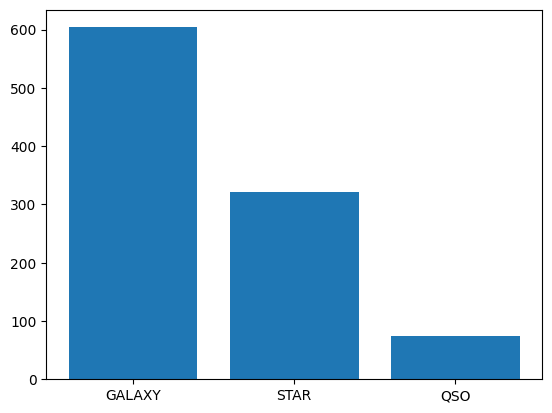

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns 

# Bar Chart Showing Classes
quasar_count = df['class'].value_counts()
plt.bar(quasar_count.index, quasar_count.values)
plt.show()

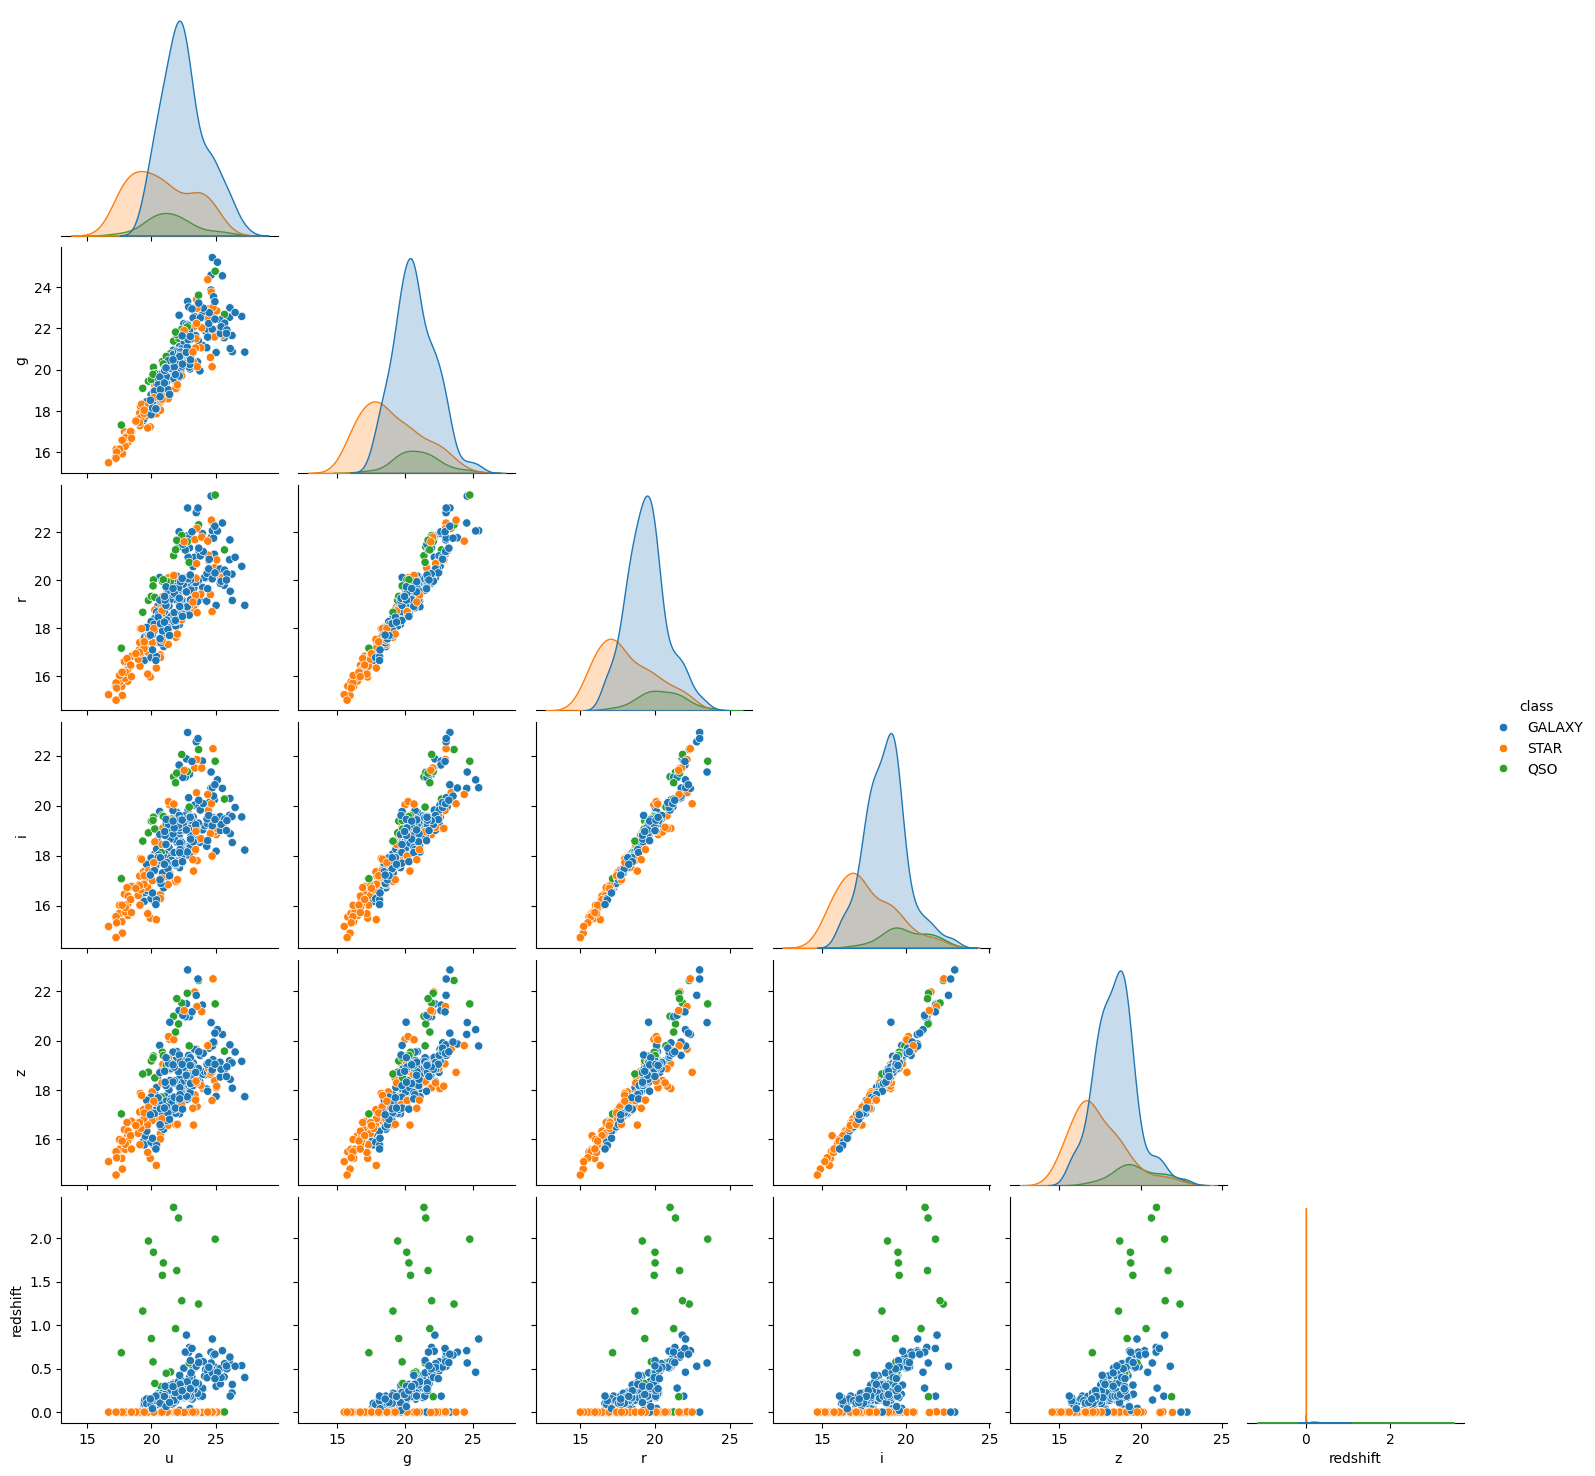

In [5]:
# Pair Plots
plot_df = df[df.columns]
sns.pairplot(plot_df.sample(300), hue='class',corner=True)
plt.show()

In [6]:
# Finding the Correlation
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

df[df.columns].corr()


,u,g,r,i,z,redshift,class
u,1.000000,0.896898,0.798409,0.028862,0.028491,0.257649,-0.371534
g,0.896898,1.000000,0.956173,-0.004060,-0.004371,0.355317,-0.380796
r,0.798409,0.956173,1.000000,0.016164,0.015989,0.401835,-0.313568
i,0.028862,-0.004060,0.016164,1.000000,1.000000,0.018290,-0.045729
z,0.028491,-0.004371,0.015989,1.000000,1.000000,0.018322,-0.045549
redshift,0.257649,0.355317,0.401835,0.018290,0.018322,1.000000,-0.159720
class,-0.371534,-0.380796,-0.313568,-0.045729,-0.045549,-0.159720,1.000000


### Step 4 : Modeling and Prediction

#### Splitting the dataset

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('class', axis = 1)
y = df['class']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=1)


#### Modeling Logistic Regression

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=1)
log_reg_model = OneVsRestClassifier(base_model)

log_reg_model.fit(X_train, y_train)
log_pred = log_reg_model.predict(X_val)



#### Modeling Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error

forest_model = RandomForestClassifier(class_weight='balanced',random_state=1)
forest_model.fit(X_train, y_train)
quasar_pred = forest_model.predict(X_val)
print(mean_absolute_error(y_val, quasar_pred))

0.05333333333333334


### Step 5: Presenting Findings in a well structured report

In [ ]:
from sklearn.metrics import classification_report


print('\n-----------Logistic Regression Results-----------')
print(classification_report(y_val, log_pred, target_names=['Galaxy', 'Quasar', 'Star']))


print('\n-----------Random Forest Results-----------')
print(classification_report(y_val, quasar_pred, target_na
mes=['Galaxy', 'Quasar', 'Star']))


-----------Logistic Regression Results-----------
              precision    recall  f1-score   support

      Galaxy       0.91      0.79      0.85       179
      Quasar       0.70      0.83      0.76        23
        Star       0.74      0.89      0.81        98

    accuracy                           0.83       300
   macro avg       0.79      0.84      0.81       300
weighted avg       0.84      0.83      0.83       300


-----------Random Forest Results-----------
              precision    recall  f1-score   support

      Galaxy       0.95      0.98      0.97       179
      Quasar       0.88      0.65      0.75        23
        Star       0.98      0.98      0.98        98

    accuracy                           0.96       300
   macro avg       0.94      0.87      0.90       300
weighted avg       0.96      0.96      0.95       300

